In [2]:
import subprocess

subprocess.run(["pip", "install", "yfinance", "--quiet"])

CompletedProcess(args=['pip', 'install', 'yfinance', '--quiet'], returncode=0)

In [3]:
import yfinance as yf

df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
close_prices = df['Close'].values
print(close_prices.shape)


[*********************100%***********************]  1 of 1 completed

(1006, 1)


In [4]:
import numpy as np
import torch

X, Y = [], []
slice_window = 30
for i in range(len(close_prices) - slice_window):
    X.append(close_prices[i:i + slice_window])
    Y.append(close_prices[i + slice_window])

X = np.array(X)
Y = np.array(Y)

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

print(X.shape)
print(Y.shape)

split = int(len(X) * 0.8)
x_train, y_train = X[:split], Y[:split]
x_test, y_test = X[split:], Y[split:]

torch.Size([976, 30, 1])
torch.Size([976, 1])


In [5]:
# Normalize using only train statistics to avoid data leakage
price_min = x_train.min()
price_max = x_train.max()

x_train = (x_train - price_min) / (price_max - price_min)
y_train = (y_train - price_min) / (price_max - price_min)
x_test = (x_test - price_min) / (price_max - price_min)
y_test = (y_test - price_min) / (price_max - price_min)

print(f"Price range used for normalization: {price_min:.2f} – {price_max:.2f}")
print(f"x_train range after norm: {x_train.min():.3f} – {x_train.max():.3f}")
print(f"y_train range after norm: {y_train.min():.3f} – {y_train.max():.3f}")


Price range used for normalization: 54.16 – 177.94
x_train range after norm: 0.000 – 1.000
y_train range after norm: 0.000 – 1.000


In [6]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(
    dataset=TensorDataset(x_train, y_train),
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    dataset=TensorDataset(x_test, y_test),
    batch_size=32,
    shuffle=False
)

In [7]:
import torch
import torch.nn as nn


class LSTMCellScratch(nn.Module):
    """Single LSTM cell — one timestep at a time."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # All 4 gates packed into one matrix multiplication for efficiency
        # W maps [h_{t-1}, x_t] -> (forget, input, candidate, output)
        self.W = nn.Linear(hidden_size + input_size, 4 * hidden_size)

    def forward(self, x_t, h_prev, c_prev):
        """
        x_t:    (batch, input_size)
        h_prev: (batch, hidden_size)
        c_prev: (batch, hidden_size)
        """
        # Concatenate previous hidden state and current input
        combined = torch.cat([h_prev, x_t], dim=1)  # (batch, hidden+input)

        # One matmul to get all 4 gates, then split
        gates = self.W(combined)  # (batch, 4*hidden)
        f, i, g, o = gates.chunk(4, dim=1)

        f_t = torch.sigmoid(f)  # forget gate
        i_t = torch.sigmoid(i)  # input gate
        g_t = torch.tanh(g)  # candidate cell
        o_t = torch.sigmoid(o)  # output gate

        c_t = f_t * c_prev + i_t * g_t  # update cell state
        h_t = o_t * torch.tanh(c_t)  # update hidden state

        return h_t, c_t


class LSTMScratch(nn.Module):
    """Full LSTM that loops over a sequence using LSTMCellScratch."""

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCellScratch(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        x shape: (batch, seq_len, input_size)
        """
        batch_size = x.size(0)

        # Initialize hidden and cell state to zeros
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)

        # Step through each timestep manually
        for t in range(x.size(1)):
            x_t = x[:, t, :]  # (batch, input_size)
            h, c = self.cell(x_t, h, c)

        # Only use the last hidden state to predict
        return self.fc(h)


# Quick sanity check
scratch_model = LSTMScratch(input_size=1, hidden_size=64, output_size=1)
dummy = torch.randn(8, 30, 1)  # batch=8, seq=30, features=1
out = scratch_model(dummy)
print("Output shape:", out.shape)  # expect (8, 1)
print("Output dtype:", out.dtype)


Output shape: torch.Size([8, 1])
Output dtype: torch.float32


In [8]:
torch.manual_seed(42)

# model = PriceLSTM(input_size=1, hidden_size=64, num_layers=1, output_size=1)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMScratch(input_size=1, hidden_size=64, output_size=1)
model = model.to(device)  # ← to(device) SAU khi tạo model mới

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # giảm lr khi loss không giảm
    factor=0.5,       # lr = lr * 0.5
    patience=50,      # chờ 10 epochs không cải thiện
)


In [9]:
num_epochs = 500
best_test_loss = float('inf')
patience = 20
no_improve = 0

for epoch in range(1, num_epochs + 1):
    model.train()
    total_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        pred = model(batch_x)

        loss = criterion(pred, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)
    scheduler.step(avg_test_loss)  # Cập nhật learning rate dựa trên test loss
    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch [{epoch}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Test Loss: {avg_test_loss:.6f}"
        )

    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        no_improve = 0
        torch.save(model.state_dict(), "best_model.pt") # Save the model
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch} due to no improvement for {patience} epochs.")
        break


Epoch [1/500] Train Loss: 0.296553 Test Loss: 0.630340
Epoch [5/500] Train Loss: 0.029669 Test Loss: 0.002848
Epoch [10/500] Train Loss: 0.010392 Test Loss: 0.001658
Epoch [15/500] Train Loss: 0.007058 Test Loss: 0.002209
Epoch [20/500] Train Loss: 0.005383 Test Loss: 0.003829
Epoch [25/500] Train Loss: 0.004420 Test Loss: 0.005618
Early stopping at epoch 26 due to no improvement for 20 epochs.


In [10]:
for name, param in model.named_parameters():
    print(name, param.shape)

cell.W.weight torch.Size([256, 65])
cell.W.bias torch.Size([256])
fc.weight torch.Size([1, 64])
fc.bias torch.Size([1])


In [11]:
print(x_test.min(), x_test.max())
print(y_test.min(), y_test.max())

tensor(0.7186) tensor(1.1450)
tensor(0.8167) tensor(1.1450)


/tmp/ipykernel_315/221826433.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


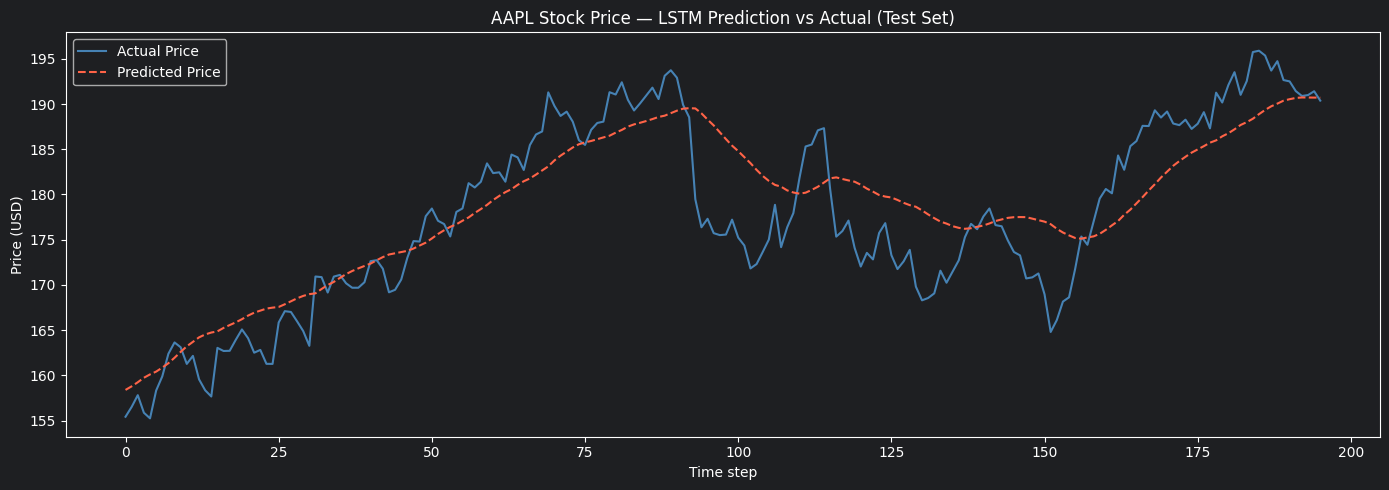

MAE:  $4.11
RMSE: $5.05


In [12]:
import matplotlib.pyplot as plt

# Load best saved model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

# Collect all predictions on test set
all_preds = []
all_actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        pred = model(batch_x)
        all_preds.append(pred.cpu())
        all_actuals.append(batch_y)

preds   = torch.cat(all_preds).numpy()
actuals = torch.cat(all_actuals).numpy()

# Denormalize back to original price scale
price_range = (price_max - price_min).item()
preds   = preds   * price_range + price_min.item()
actuals = actuals * price_range + price_min.item()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(actuals, label="Actual Price",    color="steelblue")
plt.plot(preds,   label="Predicted Price", color="tomato", linestyle="--")
plt.title("AAPL Stock Price — LSTM Prediction vs Actual (Test Set)")
plt.xlabel("Time step")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Error metrics
mae  = abs(preds - actuals).mean()
rmse = ((preds - actuals) ** 2).mean() ** 0.5
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
